<div align="center">

# COMP8420 - Use Case 1: Intelligent Customer Service System

</div>

# 01 · Data Exploration

This notebook explores the Bitext Customer Support dataset before building the full customer service system. The aim is to check whether the dataset fits Use Case 1, understand the class balance, inspect message lengths and examples, and create reproducible train/validation/test splits.

Most reusable logic is kept inside the `src/` folder, while this notebook is used for running experiments, checking outputs, and recording observations. The notebooks should be run in order from `01` to `09` after completing the setup in `README.md`.

In [1]:
# --- bootstrap: make `import config` and `from src import ...` work from anywhere ---
import sys, os
from pathlib import Path
p = Path.cwd()
ROOT = next((c for c in [p, *p.parents] if (c/'config.py').exists() and (c/'src').exists()), p)
sys.path.insert(0, str(ROOT)); os.chdir(ROOT)
print('project root:', ROOT)

project root: C:\Users\lenovo\Desktop\ANLP_8420_GROUPC\Assignment3_GroupC\Codes


## 1. Load the dataset

For this project, we use the Bitext Customer Support dataset, which contains labelled customer messages and agent-style responses. It includes intent labels and broader category labels, which makes it suitable for enquiry classification in our customer service system.

Although the assignment brief suggests the Microsoft Customer Service Dataset, we selected Bitext because it is easier to access, structured for customer support tasks, and directly supports the NLP components required in Use Case 1.

In [2]:
from src import data_loader
df = data_loader.clean(data_loader.download_dataset())
print(df.shape)
df.head(3)

[data] Using cached raw CSV: C:\Users\lenovo\Desktop\ANLP_8420_GROUPC\Assignment3_GroupC\Codes\data\raw\bitext_customer_support.csv
[data] Cleaned: 26,872 -> 24,635 rows (11 categories)
(24635, 5)


,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...


In [3]:
import config
print('text col    :', config.TEXT_COL)
print('target (cat) :', config.CATEGORY_COL)
print('intent col   :', config.INTENT_COL)
print('response col :', config.RESPONSE_COL)
df.columns.tolist()

text col    : instruction
target (cat) : category
intent col   : intent
response col : response


['flags', 'instruction', 'category', 'intent', 'response']

## 2. Class balance
We verify the category distribution and note any skew (drives our use of **macro-F1** as the primary metric).

category
ACCOUNT         5443
ORDER           3168
REFUND          2622
CONTACT         1999
PAYMENT         1998
FEEDBACK        1997
SHIPPING        1970
INVOICE         1830
DELIVERY        1659
SUBSCRIPTION     999
CANCEL           950
Name: count, dtype: int64


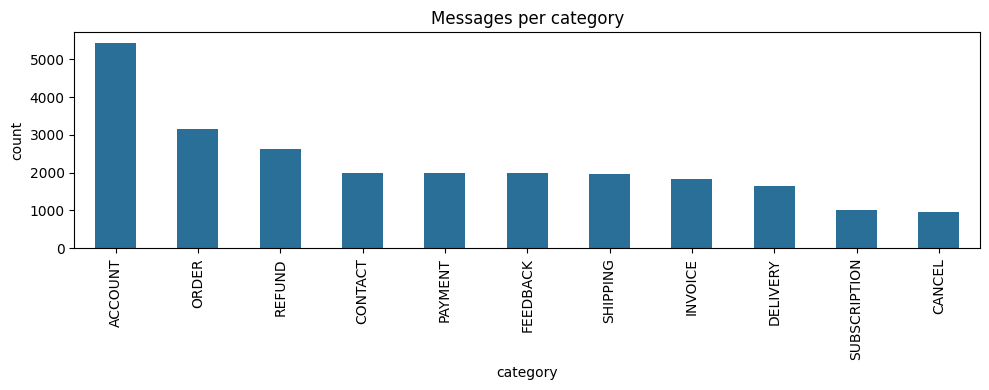

In [4]:
import matplotlib.pyplot as plt
vc = df[config.CATEGORY_COL].value_counts()
print(vc)
ax = vc.plot(kind='bar', figsize=(10,4), color='#2a6f97')
ax.set_title('Messages per category'); ax.set_ylabel('count'); plt.tight_layout(); plt.show()

## 3. Message length

We inspect the length of customer messages to understand how much context is available for classification and retrieval. Since many support enquiries are short and topic-focused, TF-IDF based models can still provide a useful baseline before applying more advanced LLM-based techniques.

count    24635.000000
mean         8.861904
std          2.567765
min          1.000000
25%          7.000000
50%          9.000000
75%         11.000000
max         16.000000
Name: n_words, dtype: float64


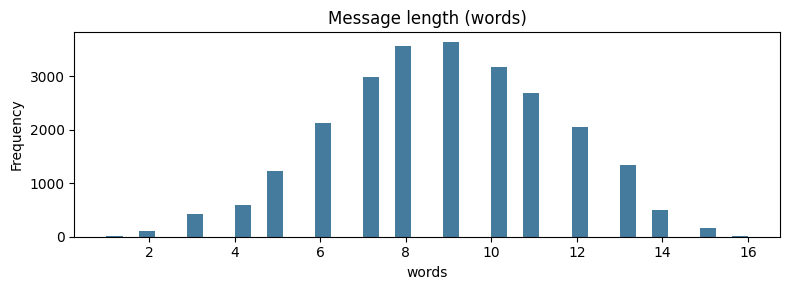

In [5]:
df['n_words'] = df[config.TEXT_COL].str.split().str.len()
print(df['n_words'].describe())
df['n_words'].plot(kind='hist', bins=40, figsize=(8,3), color='#457b9d')
plt.title('Message length (words)'); plt.xlabel('words'); plt.tight_layout(); plt.show()

## 4. Sample messages per category

In [6]:
for cat, grp in df.groupby(config.CATEGORY_COL):
    print(f'\n=== {cat} ===')
    for s in grp[config.TEXT_COL].head(2):
        print(' -', s[:110])


=== ACCOUNT ===
 - new {{Account Type}} acount for wife
 - how to open a different fucking {{Account Type}} account for my father?

=== CANCEL ===
 - I can't ifnd the bloody termination charge, I need help
 - what is the fee for canceling the contract?

=== CONTACT ===
 - I want help to speak to customer support
 - do you have a free number to talk to customer assistance?

=== DELIVERY ===
 - could you help me check what delivery methods you offer?
 - can you help me see what shipping methods you offer?

=== FEEDBACK ===
 - help me to file a claim
 - where can i make a consumer claim against ur organization

=== INVOICE ===
 - show me invoice{{Invoice Number}}
 - need to see my invoicesfrom {{Person Name}}

=== ORDER ===
 - question about cancelling order {{Order Number}}
 - i have a question about cancelling oorder {{Order Number}}

=== PAYMENT ===
 - I try to list your available payment methoids
 - I nneed help to list the accepted payment methods

=== REFUND ===
 - i do not know ho

## 5. Data quality report

In [7]:
print('missing per column:\n', df.isna().sum())
print('\nduplicate messages:', df[config.TEXT_COL].duplicated().sum())
if config.INTENT_COL in df.columns:
    print('\nintents (fine labels):', df[config.INTENT_COL].nunique())

missing per column:
 flags          0
instruction    0
category       0
intent         0
response       0
n_words        0
dtype: int64

duplicate messages: 0

intents (fine labels): 27


## 6. Reproducible splits
Stratified **70/15/15** on the category label with a fixed seed so every split contains all classes and results reproduce exactly.

In [8]:
train, val, test = data_loader.make_splits(df)
print('train', train.shape, '| val', val.shape, '| test', test.shape)

[data] Splits  train=17,244  val=3,695  test=3,696
train (17244, 6) | val (3695, 6) | test (3696, 6)


## Summary

This notebook confirms that the dataset is suitable for the selected customer service use case. The category labels are available for classification, the message length distribution is appropriate for both traditional NLP and LLM-based methods, and stratified train/validation/test splits have been saved under `data/processed/`.

The next notebook builds the preprocessing pipeline and applies PII redaction to support cleaner and more responsible text processing.